<a href="https://colab.research.google.com/github/aminmoosavi/__PyTorch__/blob/main/PyTorch_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PyTorch Day-4**

**In this notebook we will learn to solve a Multi-Class classification problem with neural networks**


* ### Checking the gpu

In [1]:
!nvidia-smi

Tue Jul  7 22:29:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P8             15W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Use gpu if available
device = "cuda" if torch.cuda.is_available() else "cpu"

* # The data.

**We want to do a multiclass classification of 4 data classes**

* $y_1 = a_1 x^2 + b_1 x + c_1 + \eta_1$
* $y_2 = a_2 x^2 + b_2 x + c_2 + \eta_2$
* $y_3 = a_3 x^2 + b_3 x + c_3 + \eta_3$
* $y_4 = a_4 x^2 + b_4 x + c_4 + \eta_4$

**where $\eta_i$ for i=1,2,3,4 are Gaussian noises**


In [4]:
# parameters to generate data
a0 , b0 , c0 = 1/4 , -2/4 , 4
a1 , b1 , c1 = 1/2 , -2/2 , 10
a2 , b2 , c2 = 1 , -2 , 16
a3 , b3 , c3 = 2 , -4 , 25
# domain of x variable
x_min , x_max = -4 ,  6

# Setting the random seed
torch.manual_seed(21)

# Input data x axis
X0 = (x_max - x_min) * torch.rand(1000, 1) + x_min
X1 = (x_max - x_min) * torch.rand(1000, 1) + x_min
X2 = (x_max - x_min) * torch.rand(1000, 1) + x_min
X3 = (x_max - x_min) * torch.rand(1000, 1) + x_min

# Input data y axis
Y0 = a0 * X0**2 + b0 * X0 + c0 + torch.randn(X2.size())
Y1 = a1 * X1**2 + b1 * X1 + c1 + torch.randn(X1.size())
Y2 = a2 * X2**2 + b2 * X2 + c2 + torch.randn(X2.size())
Y3 = a3 * X3**2 + b3 * X3 + c3 + torch.randn(X3.size())


# Observed output labels
y0 = 0 * torch.ones(X0.size())
y1 = 1 * torch.ones(X1.size())
y2 = 2 * torch.ones(X2.size())
y3 = 3 * torch.ones(X3.size())


# Concatenating two labels and corresponding input
XX = torch.cat( ( X0 , X1 , X2 , X3), dim = 0) # <-- Data first dimension
YY = torch.cat( ( Y0 , Y1 , Y2 , Y3), dim = 0) # <-- Data second dimension
y = torch.cat( ( y0 , y1 , y2 ,y3), dim = 0) # <-- Labels

# randomly permute the data
shuffled_indices = torch.randperm(XX.size()[0])

XX = XX[shuffled_indices]
YY = YY[shuffled_indices]
y = y[shuffled_indices] # <-- One dimensional labels (zeros and ones)

# Putting two dimensional inputs in a 2d tensor
X = torch.cat((XX,YY),dim=1) # <-- Two dimensional input


# Moving the data to gpu if available
print(
    'The data is on', X.device, '. Moving the data to gpu if available'
    ) if X.device.type=="cpu" else print('-->')

X = X.to(device)
y = y.to(device)
y = y.squeeze()
y = y.long()  # <- Make sure that labels are integer values
print('The data is on', X.device.type, 'now')
X.requires_grad = False
y.requires_grad = False

The data is on cpu . Moving the data to gpu if available
The data is on cuda now


* # Visualize the data

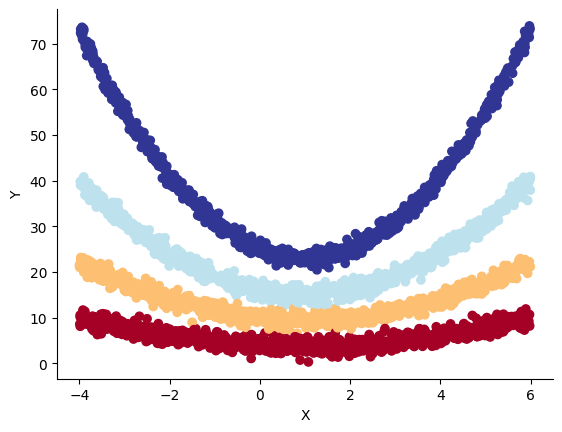

In [5]:
fig, ax = plt.subplots()
ax.scatter( X.cpu()[:,0] , X.cpu()[:,1] , c=y.cpu() , cmap=plt.cm.RdYlBu)
ax.set_ylabel('Y')
ax.set_xlabel('X')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

* # Splitting the data into training and test sets

In [6]:
train_split = int(0.75 * len(y))

# Splitting the data
X_train , y_train = X[:train_split,:]  , y[:train_split]
X_test , y_test = X[train_split:,:]  , y[train_split:]
y_train.dtype

torch.int64

* # Building the model

* **Because the input is two dimensional the in_features of layer 1 must be 2.**

* **The out_features of layer 1 must be equal to the in_features of layer 2.**

* **The output of the model are 4 real valued numbers for 4 different classes. These numbers are called logits (they will be passed to a softmax that gives us probability of the input being in class red or class black)**

In [7]:
class MultiClassificationModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2 , out_features=100)
    self.layer2 = nn.Linear(in_features=100 , out_features=4)
    self.activation = nn.ReLU()

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    x = self.layer1(x)
    x = self.activation(x)
    x = self.layer2(x)
    return x

In [8]:
# Instantiate the model
model_4 = MultiClassificationModel()

# Sending the model to gpu
model_4.to(device)

# Looking at model's attributes
list(model_4.state_dict())

['layer1.weight', 'layer1.bias', 'layer2.weight', 'layer2.bias']

* # Setting the loss function
The cross entropy loss in PyTorch gets the logits, pass them through Softmax function to get probabilities and uses the probabilities to calculate the loss.

In [9]:
loss_fn = nn.CrossEntropyLoss()

* # Setting the optimizer

In [10]:
optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.01)

* # Training

In [11]:
epochs = 3000


# To save loss values for future visualization
losses=torch.zeros(epochs, requires_grad=False)
losses_test=torch.zeros(epochs, requires_grad=False)

# Start training
for epoch in range(epochs):
  model_4.train() # training mode activated

  #1. forward pass
  y_logits = model_4(X_train)

  #2. Compute the loss
  loss=loss_fn(y_logits,y_train)
  losses[epoch]=loss # save the loss

  #3. Optimizer zero grad resets the gradient to zero
  optimizer.zero_grad()

  #4. Perform backpropagation
  loss.backward()

  #5. Step the optimizer (gradient descent)
  optimizer.step()

  #6. Look at how the model does on the test data
  model_4.eval() # Evaluation mode activated
  with torch.inference_mode():
    # forward pass the test data
    Y_logit_test = model_4(X_test)

    # calculate test loss
    loss_test=loss_fn(Y_logit_test,y_test)
    losses_test[epoch] = loss_test # save the loss


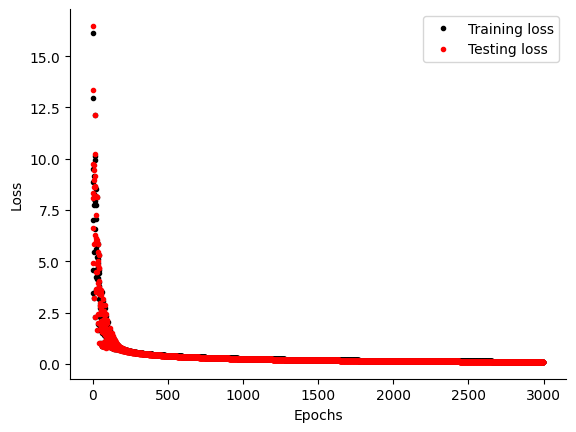

In [12]:
# Casting the loss tensors into NumPy arrays
lossvals=losses.detach().numpy()
lossvals_test=losses_test.detach().numpy()

# Plotting the loss functions
fig, ax = plt.subplots()
plt.plot(lossvals,'.',color='k',label = 'Training loss')
ax.plot(lossvals_test,'.',color='r',label = 'Testing loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()

* # Predicting the output labels of the test data
* **Sampling a multinomial distribution**

or

* **Finding the max probability**

In [13]:
from torch.distributions.multinomial import Multinomial

model_4.eval()
with torch.inference_mode():
  Y_logit_test = model_4(X_test)

probabilities = torch.softmax(Y_logit_test , dim=1)
# y_test_pred = torch.multinomial(probabilities,
#                                 num_samples=1).squeeze(1) # <- Multinomial samping
y_test_pred = torch.argmax(probabilities, dim=1) # <- Taking the max probability

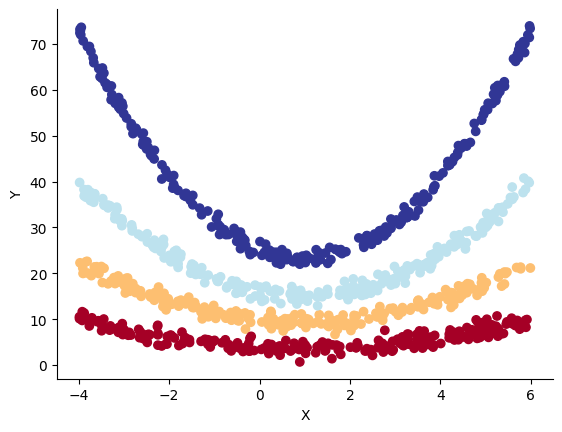

In [14]:
fig, ax = plt.subplots()
ax.scatter( X_test.cpu()[:,0] , X_test.cpu()[:,1] , c=y_test_pred.cpu() , cmap=plt.cm.RdYlBu)
ax.set_ylabel('Y')
ax.set_xlabel('X')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()